# 5. Cluster Analysis and Conclusion

This notebook interprets the clustering solution selected in the previous stage. It combines the cleaned post attributes, PCA scores, cluster assignments, and model-selection diagnostics to describe the groups in business-readable terms.

Cluster identifiers are arbitrary labels rather than ordered categories. The analysis is descriptive and exploratory; it does not establish that a content type or publication time causes higher engagement.

## 5.1. Environment and Library Imports

In [1]:
# Standard library imports
import logging
import sys
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
current_directory = Path.cwd().resolve()
project_candidates = (current_directory, *current_directory.parents)

PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "src").is_dir()),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root directory.")

SRC_DIRECTORY = PROJECT_ROOT / "src"

if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)

LOGGER = logging.getLogger("facebook_clustering.cluster_analysis")

### 5.1.1. Custom Utilities

In [4]:
from data_collection_utils import (
    save_dataframe_csv,
    validate_dataframe_contract,
)

## 5.2. Configuration

All inputs are artifacts created by notebooks 02–04. The outputs of this notebook are compact analytical tables and figures that support the final interpretation.

In [5]:
CLEANED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "facebook_posts_cleaned.csv"
)
PCA_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "facebook_posts_pca.csv"
)
CLUSTER_LABELS_PATH = (
    PROJECT_ROOT / "data" / "processed" / "selected_cluster_labels.csv"
)
CANDIDATE_RESULTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering_candidate_results.csv"
)
MODEL_COMPARISON_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering_model_comparison.csv"
)
EXPLAINED_VARIANCE_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pca_explained_variance.csv"
)
COMPONENT_WEIGHTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "pca_component_weights.csv"
)

CLUSTER_PROFILES_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cluster_profiles.csv"
)
STATUS_DISTRIBUTION_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cluster_status_type_distribution.csv"
)
TEMPORAL_PROFILES_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cluster_temporal_profiles.csv"
)
ASSOCIATION_SUMMARY_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cluster_association_summary.csv"
)
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"

RECORD_ID_COLUMN = "record_id"
CLUSTER_COLUMN = "cluster"
STATUS_TYPE_COLUMN = "status_type"

ENGAGEMENT_COLUMNS = [
    "num_reactions",
    "num_comments",
    "num_shares",
    "num_likes",
    "num_loves",
    "num_wows",
    "num_hahas",
    "num_sads",
    "num_angrys",
]
CORE_ENGAGEMENT_COLUMNS = [
    "num_reactions",
    "num_comments",
    "num_shares",
]
WEEKDAY_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
DAYPART_LABELS = [
    "00:00–05:59",
    "06:00–11:59",
    "12:00–17:59",
    "18:00–23:59",
]

## 5.3. Artifact Loading and Validation

The joins use the persistent record identifier created during preprocessing. One-to-one validation prevents silent row duplication or label misalignment.

In [6]:
required_input_paths = [
    CLEANED_DATA_PATH,
    PCA_DATA_PATH,
    CLUSTER_LABELS_PATH,
    CANDIDATE_RESULTS_PATH,
    MODEL_COMPARISON_PATH,
    EXPLAINED_VARIANCE_PATH,
    COMPONENT_WEIGHTS_PATH,
]
missing_input_paths = [
    path for path in required_input_paths if not path.exists()
]

if missing_input_paths:
    missing_paths = ", ".join(str(path) for path in missing_input_paths)
    raise FileNotFoundError(
        "Required artifacts were not found. Run notebooks 02–04 first: "
        f"{missing_paths}"
    )

cleaned_posts = pd.read_csv(
    CLEANED_DATA_PATH,
    parse_dates=["published_at"],
)
pca_data = pd.read_csv(PCA_DATA_PATH)
cluster_labels = pd.read_csv(CLUSTER_LABELS_PATH)
candidate_results = pd.read_csv(CANDIDATE_RESULTS_PATH)
model_comparison = pd.read_csv(MODEL_COMPARISON_PATH)
explained_variance = pd.read_csv(EXPLAINED_VARIANCE_PATH)
component_weights = pd.read_csv(COMPONENT_WEIGHTS_PATH)

validate_dataframe_contract(
    cleaned_posts,
    required_columns={
        RECORD_ID_COLUMN,
        STATUS_TYPE_COLUMN,
        "published_at",
        "publication_year",
        "publication_month",
        "publication_weekday",
        "publication_hour",
        *ENGAGEMENT_COLUMNS,
    },
)
validate_dataframe_contract(
    pca_data,
    required_columns={RECORD_ID_COLUMN, "PC1", "PC2"},
)
validate_dataframe_contract(
    cluster_labels,
    required_columns={RECORD_ID_COLUMN, CLUSTER_COLUMN},
)
validate_dataframe_contract(
    candidate_results,
    required_columns={
        "algorithm",
        "eligible",
        "silhouette_score",
    },
)
validate_dataframe_contract(
    model_comparison,
    required_columns={
        "algorithm",
        "selected",
        "stable",
        "silhouette_score",
        "calinski_harabasz_score",
        "davies_bouldin_score",
        "stability_ari_mean",
        "maximum_cluster_share",
    },
)
validate_dataframe_contract(
    explained_variance,
    required_columns={
        "component",
        "explained_variance_ratio",
        "cumulative_variance_ratio",
    },
)
validate_dataframe_contract(
    component_weights,
    required_columns={"feature", "PC1", "PC2"},
)

for table_name, dataframe in {
    "cleaned posts": cleaned_posts,
    "PCA scores": pca_data,
    "cluster labels": cluster_labels,
}.items():
    if dataframe[RECORD_ID_COLUMN].duplicated().any():
        raise ValueError(
            f"Duplicated record identifiers found in {table_name}."
        )

if int(model_comparison["selected"].sum()) != 1:
    raise ValueError(
        "The model comparison must contain exactly one selected candidate."
    )

analysis_data = cleaned_posts.merge(
    cluster_labels,
    on=RECORD_ID_COLUMN,
    how="inner",
    validate="one_to_one",
)
pca_analysis = pca_data.merge(
    cluster_labels,
    on=RECORD_ID_COLUMN,
    how="inner",
    validate="one_to_one",
)

expected_record_ids = set(cleaned_posts[RECORD_ID_COLUMN])
if set(analysis_data[RECORD_ID_COLUMN]) != expected_record_ids:
    raise ValueError("Some cleaned records do not have a cluster assignment.")

if set(pca_analysis[RECORD_ID_COLUMN]) != expected_record_ids:
    raise ValueError("PCA scores and cleaned records are not aligned.")

LOGGER.info(
    "Analysis artifacts loaded successfully: observations=%d, clusters=%d",
    len(analysis_data),
    analysis_data[CLUSTER_COLUMN].nunique(),
)

2026-07-19 20:54:11,600 | INFO | Analysis artifacts loaded successfully: observations=7050, clusters=2


## 5.4. Selected Model and Reduction Summary

The revised workflow does not select a model from the Silhouette Score alone. Candidate eligibility, cluster size, coverage, complementary quality metrics, and perturbation stability are considered together.

In [7]:
selected_model = model_comparison.loc[
    model_comparison["selected"]
].iloc[0]

candidate_family_summary = (
    candidate_results.groupby("algorithm", as_index=False)
    .agg(
        candidate_count=("algorithm", "size"),
        eligible_candidate_count=("eligible", "sum"),
        best_observed_silhouette=("silhouette_score", "max"),
    )
    .sort_values("algorithm")
)

eligible_candidate_scores = (
    candidate_results.loc[candidate_results["eligible"]]
    .groupby("algorithm")["silhouette_score"]
    .max()
    .rename("best_eligible_silhouette")
)
candidate_family_summary = candidate_family_summary.join(
    eligible_candidate_scores,
    on="algorithm",
)

component_columns = sorted(
    [
        column
        for column in pca_data.columns
        if column.startswith("PC") and column[2:].isdigit()
    ],
    key=lambda column: int(column[2:]),
)
selected_component_count = len(component_columns)
retained_variance = float(
    explained_variance.loc[
        explained_variance["component"] == selected_component_count,
        "cumulative_variance_ratio",
    ].iloc[0]
)

selected_model_summary = pd.Series(
    {
        "algorithm": selected_model["algorithm"],
        "cluster_count": int(selected_model["cluster_count"]),
        "coverage": selected_model["coverage"],
        "silhouette_score": selected_model["silhouette_score"],
        "calinski_harabasz_score": (
            selected_model["calinski_harabasz_score"]
        ),
        "davies_bouldin_score": selected_model["davies_bouldin_score"],
        "stability_ari_mean": selected_model["stability_ari_mean"],
        "maximum_cluster_share": selected_model["maximum_cluster_share"],
        "selected_pca_components": selected_component_count,
        "retained_pca_variance": retained_variance,
    },
    name="value",
)

display(candidate_family_summary)
display(selected_model_summary.to_frame())

,algorithm,candidate_count,eligible_candidate_count,best_observed_silhouette,best_eligible_silhouette
0,Agglomerative Clustering,84,19,0.626881,0.364350
1,DBSCAN,24,0,0.486929,NaN
2,K-Means,14,14,0.361583,0.361583


,value
algorithm,Agglomerative Clustering
cluster_count,2
coverage,1.0
silhouette_score,0.36435
calinski_harabasz_score,2346.167398
davies_bouldin_score,1.341639
stability_ari_mean,0.967094
maximum_cluster_share,0.838723
selected_pca_components,10
retained_pca_variance,0.877934


## 5.5. Cluster Population and Balance

Cluster sizes are examined before behavioral profiles because a global metric can hide a small or weakly defined group.

In [8]:
cluster_size_summary = (
    analysis_data[CLUSTER_COLUMN]
    .value_counts()
    .sort_index()
    .rename("post_count")
    .to_frame()
)
cluster_size_summary["post_share"] = (
    cluster_size_summary["post_count"] / len(analysis_data)
)
cluster_size_summary["is_noise"] = (cluster_size_summary.index == -1)
cluster_size_summary.index.name = CLUSTER_COLUMN

non_noise_sizes = cluster_size_summary.loc[
    ~cluster_size_summary["is_noise"],
    "post_count",
]
cluster_imbalance_ratio = (
    float(non_noise_sizes.max() / non_noise_sizes.min())
    if len(non_noise_sizes) > 1
    else 1.0
)

LOGGER.info(
    "Largest cluster share: %.2f%%",
    cluster_size_summary["post_share"].max() * 100,
)
LOGGER.info(
    "Largest-to-smallest non-noise cluster ratio: %.2f",
    cluster_imbalance_ratio,
)

display(
    cluster_size_summary.assign(
        post_share_pct=lambda dataframe: dataframe["post_share"] * 100
    )
)

2026-07-19 20:54:11,686 | INFO | Largest cluster share: 83.87%
2026-07-19 20:54:11,687 | INFO | Largest-to-smallest non-noise cluster ratio: 5.20


,post_count,post_share,is_noise,post_share_pct
cluster,,,,
0,5913,0.838723,False,83.87234
1,1137,0.161277,False,16.12766


2026-07-19 20:54:11,763 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-19 20:54:11,772 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


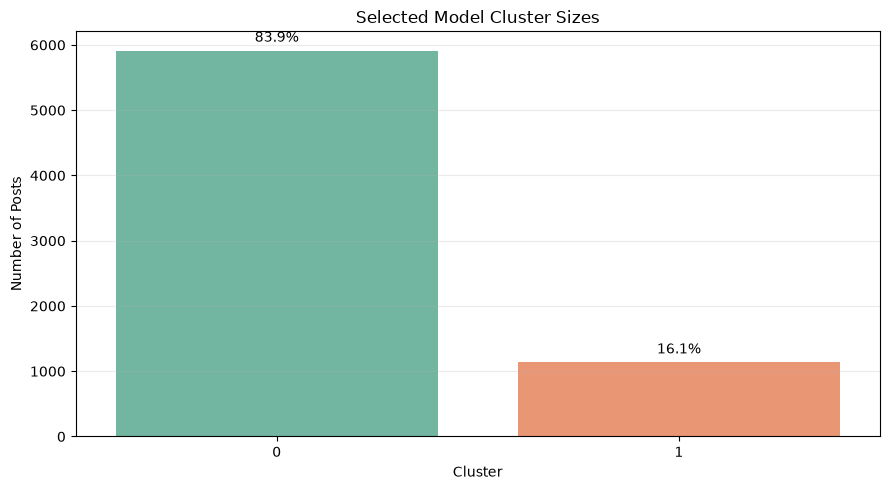

In [9]:
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
size_plot = cluster_size_summary.reset_index()
sns.barplot(
    data=size_plot,
    x=CLUSTER_COLUMN,
    y="post_count",
    hue=CLUSTER_COLUMN,
    palette="Set2",
    legend=False,
    ax=ax,
)

for patch, share in zip(
    ax.patches,
    size_plot["post_share"],
):
    ax.annotate(
        f"{share:.1%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 4),
        textcoords="offset points",
    )

ax.set(
    title="Selected Model Cluster Sizes",
    xlabel="Cluster",
    ylabel="Number of Posts",
)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "cluster_analysis_sizes.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 5.6. Engagement Profiles

Engagement variables are strongly right-skewed, so means and medians are retained together. Medians describe a typical post, while means preserve information about highly successful posts.

In [10]:
cluster_means = (
    analysis_data.groupby(CLUSTER_COLUMN)[ENGAGEMENT_COLUMNS]
    .mean()
    .sort_index()
)
cluster_medians = (
    analysis_data.groupby(CLUSTER_COLUMN)[ENGAGEMENT_COLUMNS]
    .median()
    .sort_index()
)

cluster_profiles = cluster_size_summary.join(
    cluster_means.add_prefix("mean_")
).join(
    cluster_medians.add_prefix("median_")
)
cluster_profiles["median_core_engagement"] = cluster_medians[
    CORE_ENGAGEMENT_COLUMNS
].sum(axis=1)
cluster_profiles["engagement_rank"] = (
    cluster_profiles["median_core_engagement"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

engagement_profile_columns = [
    "post_count",
    "post_share",
    "median_core_engagement",
    "engagement_rank",
    *[
        f"median_{column}"
        for column in CORE_ENGAGEMENT_COLUMNS
    ],
    *[
        f"mean_{column}"
        for column in CORE_ENGAGEMENT_COLUMNS
    ],
]

display(cluster_profiles[engagement_profile_columns].round(2))

,post_count,post_share,median_core_engagement,engagement_rank,median_num_reactions,median_num_comments,median_num_shares,mean_num_reactions,mean_num_comments,mean_num_shares
cluster,,,,,,,,,,
0,5913,0.84,40.0,1,38.0,2.0,0.0,206.90,14.35,2.70
1,1137,0.16,1113.0,2,229.0,709.0,175.0,350.87,1316.51,234.14


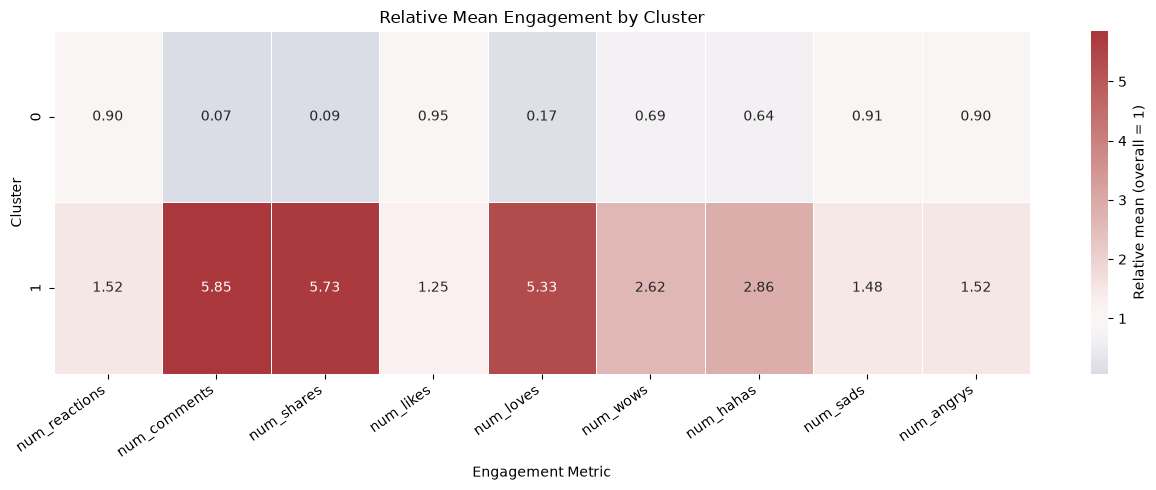

In [11]:
overall_engagement_means = analysis_data[
    ENGAGEMENT_COLUMNS
].mean()
relative_engagement_means = (
    cluster_means.add(1)
    .div(overall_engagement_means.add(1), axis="columns")
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    relative_engagement_means,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=1,
    linewidths=0.5,
    cbar_kws={"label": "Relative mean (overall = 1)"},
    ax=ax,
)
ax.set(
    title="Relative Mean Engagement by Cluster",
    xlabel="Engagement Metric",
    ylabel="Cluster",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "cluster_engagement_profiles.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 5.7. Content-Type Composition

The content-type distribution reveals whether clusters represent engagement intensity alone or also separate different publication formats.

In [12]:
status_type_counts = pd.crosstab(
    analysis_data[CLUSTER_COLUMN],
    analysis_data[STATUS_TYPE_COLUMN],
).sort_index()
status_type_shares = status_type_counts.div(
    status_type_counts.sum(axis=1),
    axis="index",
)

dominant_status_type = status_type_shares.idxmax(axis=1)
dominant_status_share = status_type_shares.max(axis=1)

cluster_profiles["dominant_status_type"] = dominant_status_type
cluster_profiles["dominant_status_share"] = dominant_status_share

status_type_distribution = pd.concat(
    [
        status_type_counts.stack().rename("post_count"),
        status_type_shares.stack().rename("cluster_share"),
    ],
    axis="columns",
).reset_index()

display((status_type_shares * 100).round(2))

status_type,link,photo,status,video
cluster,,,,
0,1.07,71.54,6.11,21.29
1,0.00,5.10,0.35,94.55


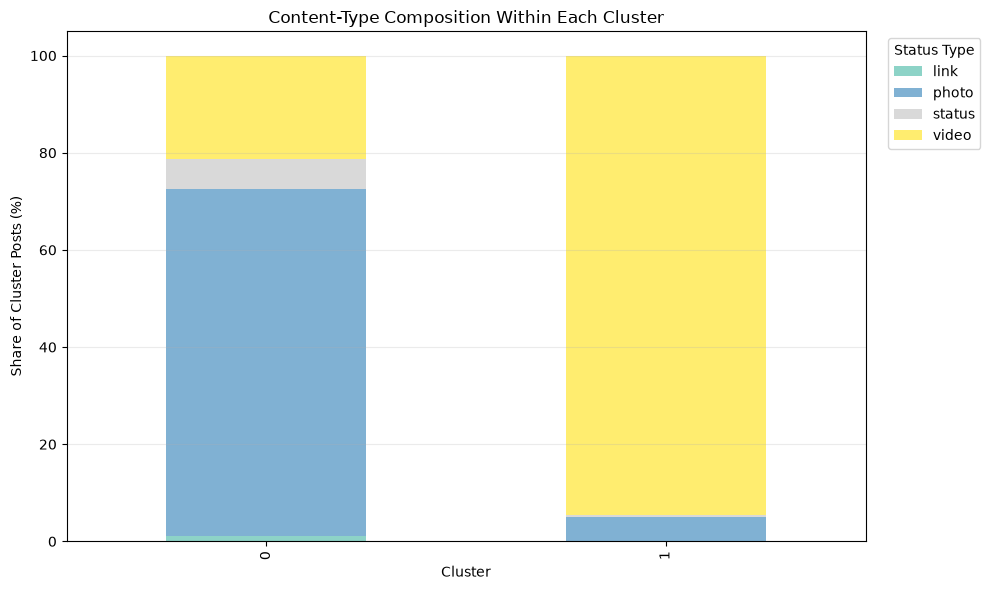

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
(status_type_shares * 100).plot(
    kind="bar",
    stacked=True,
    colormap="Set3",
    ax=ax,
)
ax.set(
    title="Content-Type Composition Within Each Cluster",
    xlabel="Cluster",
    ylabel="Share of Cluster Posts (%)",
)
ax.legend(
    title="Status Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "cluster_status_type_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 5.8. Temporal Patterns

Weekday and daypart distributions are normalized within each cluster. This makes groups of different sizes comparable and helps distinguish substantial patterns from simple volume differences.

In [14]:
analysis_data["publication_daypart"] = pd.cut(
    analysis_data["publication_hour"],
    bins=[0, 6, 12, 18, 24],
    labels=DAYPART_LABELS,
    right=False,
    include_lowest=True,
)

temporal_profiles = (
    analysis_data.groupby(CLUSTER_COLUMN)
    .agg(
        mean_publication_year=("publication_year", "mean"),
        mean_publication_month=("publication_month", "mean"),
        mean_publication_hour=("publication_hour", "mean"),
        median_publication_hour=("publication_hour", "median"),
    )
    .sort_index()
)

weekday_distribution = pd.crosstab(
    analysis_data[CLUSTER_COLUMN],
    analysis_data["publication_weekday"],
    normalize="index",
).reindex(columns=WEEKDAY_ORDER, fill_value=0)

daypart_distribution = pd.crosstab(
    analysis_data[CLUSTER_COLUMN],
    analysis_data["publication_daypart"],
    normalize="index",
).reindex(columns=DAYPART_LABELS, fill_value=0)

display(temporal_profiles.round(2))
display((weekday_distribution * 100).round(2))
display((daypart_distribution * 100).round(2))

,mean_publication_year,mean_publication_month,mean_publication_hour,median_publication_hour
cluster,,,,
0,2016.16,6.61,8.47,7.13
1,2017.54,6.39,7.35,7.03


publication_weekday,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
cluster,,,,,,,
0,14.22,14.63,13.90,13.78,14.34,13.78,15.34
1,13.46,15.48,13.98,14.78,14.25,14.69,13.37


publication_daypart,00:00–05:59,06:00–11:59,12:00–17:59,18:00–23:59
cluster,,,,
0,43.16,37.78,2.69,16.37
1,39.23,47.67,1.76,11.35


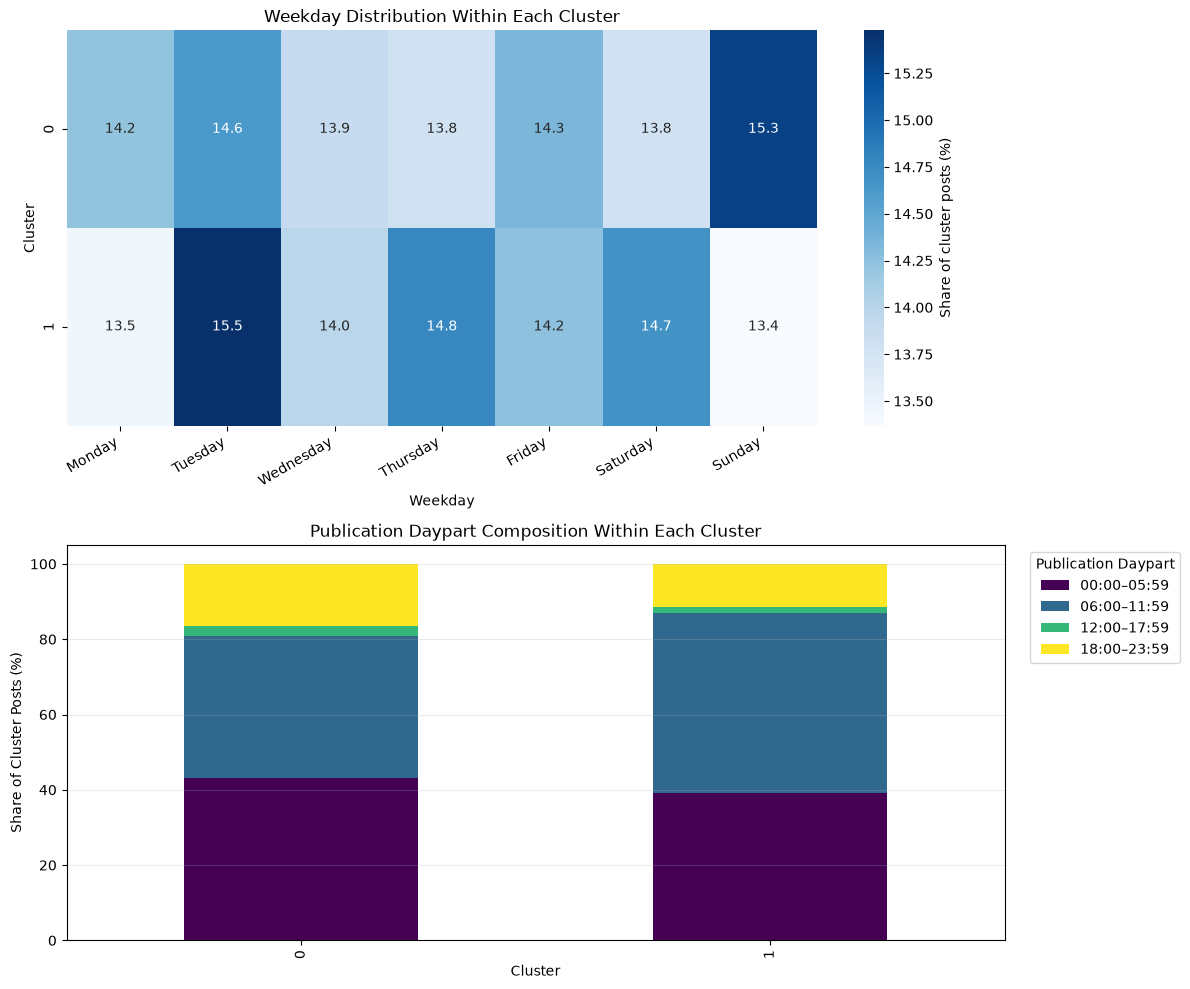

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.heatmap(
    weekday_distribution * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Share of cluster posts (%)"},
    ax=axes[0],
)
axes[0].set(
    title="Weekday Distribution Within Each Cluster",
    xlabel="Weekday",
    ylabel="Cluster",
)
axes[0].set_xticklabels(
    axes[0].get_xticklabels(),
    rotation=30,
    ha="right",
)

(daypart_distribution * 100).plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    ax=axes[1],
)
axes[1].set(
    title="Publication Daypart Composition Within Each Cluster",
    xlabel="Cluster",
    ylabel="Share of Cluster Posts (%)",
)
axes[1].legend(
    title="Publication Daypart",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "cluster_temporal_patterns.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 5.9. PCA-Space Interpretation

Cluster centroids in PCA space show the directions that separate the groups. Component weights then connect those directions back to the transformed input features.

In [16]:
pca_cluster_centroids = (
    pca_analysis.groupby(CLUSTER_COLUMN)[component_columns]
    .mean()
    .sort_index()
)

components_to_interpret = component_columns[:3]
component_weight_matrix = component_weights.set_index("feature")
top_component_features = []

for component in components_to_interpret:
    top_features = (
        component_weight_matrix[component]
        .abs()
        .nlargest(5)
        .index
    )

    for feature in top_features:
        weight = component_weight_matrix.loc[feature, component]
        top_component_features.append(
            {
                "component": component,
                "feature": feature,
                "weight": weight,
                "absolute_weight": abs(weight),
                "direction": "positive" if weight >= 0 else "negative",
            }
        )

top_component_features = pd.DataFrame(top_component_features)

display(pca_cluster_centroids[components_to_interpret].round(3))
display(top_component_features)

,PC1,PC2,PC3
cluster,,,
0,-0.795,0.000,0.023
1,4.134,-0.001,-0.121


,component,feature,weight,absolute_weight,direction
0,PC1,num_loves,0.419457,0.419457,positive
1,PC1,num_shares,0.407152,0.407152,positive
2,PC1,num_comments,0.404573,0.404573,positive
3,PC1,num_hahas,0.370552,0.370552,positive
4,PC1,num_wows,0.314081,0.314081,positive
5,PC2,publication_hour_cos,0.674651,0.674651,positive
6,PC2,publication_hour_sin,-0.645947,0.645947,negative
7,PC2,publication_month_sin,0.230338,0.230338,positive
8,PC2,publication_year,0.199164,0.199164,positive
9,PC2,num_sads,-0.108334,0.108334,negative


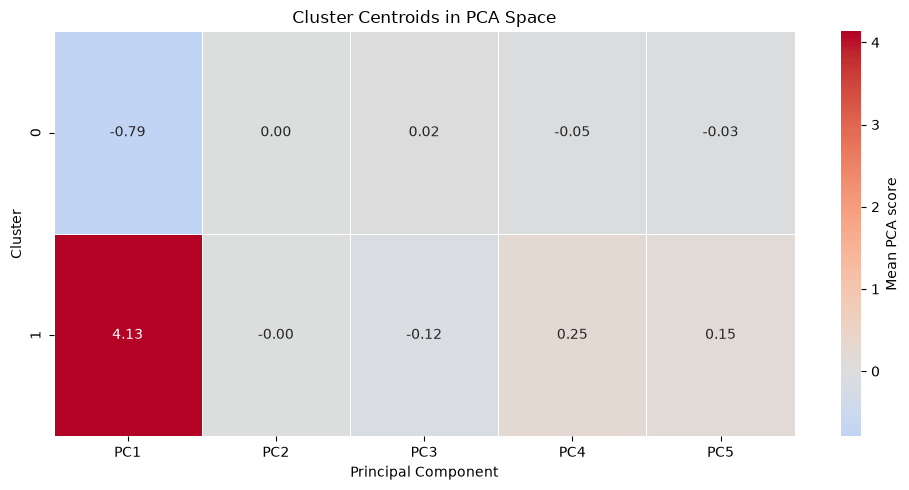

In [17]:
centroid_components = component_columns[
    : min(5, len(component_columns))
]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pca_cluster_centroids[centroid_components],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean PCA score"},
    ax=ax,
)
ax.set(
    title="Cluster Centroids in PCA Space",
    xlabel="Principal Component",
    ylabel="Cluster",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "cluster_pca_centroids.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 5.10. Categorical Association Strength

Cramér's V summarizes the association between cluster membership and categorical post attributes. It ranges from 0 (no association) to 1 (perfect association) and complements the distribution tables.

In [18]:
def calculate_cramers_v(
    left_values: pd.Series,
    right_values: pd.Series,
) -> float:
    """Calculate Cramér's V from two categorical series."""
    contingency = pd.crosstab(left_values, right_values)
    observed = contingency.to_numpy(dtype=float)
    observation_count = observed.sum()
    expected = np.outer(
        observed.sum(axis=1),
        observed.sum(axis=0),
    ) / observation_count

    chi_squared = np.divide(
        (observed - expected) ** 2,
        expected,
        out=np.zeros_like(expected),
        where=expected > 0,
    ).sum()
    minimum_dimension = min(
        observed.shape[0] - 1,
        observed.shape[1] - 1,
    )

    if observation_count == 0 or minimum_dimension == 0:
        return float("nan")

    return float(
        np.sqrt(
            chi_squared
            / (observation_count * minimum_dimension)
        )
    )


def classify_association(value: float) -> str:
    """Return a compact descriptive band for an association value."""
    if np.isnan(value):
        return "undefined"
    if value < 0.10:
        return "negligible"
    if value < 0.30:
        return "weak"
    if value < 0.50:
        return "moderate"
    return "strong"

In [19]:
association_variables = {
    "status_type": analysis_data[STATUS_TYPE_COLUMN],
    "publication_weekday": analysis_data["publication_weekday"],
    "publication_daypart": analysis_data["publication_daypart"],
}

association_summary = pd.DataFrame(
    [
        {
            "variable": variable,
            "cramers_v": calculate_cramers_v(
                analysis_data[CLUSTER_COLUMN],
                values,
            ),
        }
        for variable, values in association_variables.items()
    ]
)
association_summary["strength"] = association_summary[
    "cramers_v"
].map(classify_association)
association_summary = association_summary.sort_values(
    "cramers_v",
    ascending=False,
    ignore_index=True,
)

display(association_summary.round({"cramers_v": 3}))

,variable,cramers_v,strength
0,status_type,0.573,strong
1,publication_daypart,0.081,negligible
2,publication_weekday,0.025,negligible


## 5.11. Key Findings

In [20]:
highest_engagement_cluster = int(
    cluster_profiles["median_core_engagement"].idxmax()
)
highest_engagement_profile = cluster_profiles.loc[
    highest_engagement_cluster
]
strongest_association = association_summary.iloc[0]

final_summary = pd.Series(
    {
        "selected_algorithm": selected_model["algorithm"],
        "selected_cluster_count": int(selected_model["cluster_count"]),
        "silhouette_score": selected_model["silhouette_score"],
        "stability_ari_mean": selected_model["stability_ari_mean"],
        "retained_pca_variance": retained_variance,
        "largest_cluster_share": cluster_size_summary[
            "post_share"
        ].max(),
        "highest_engagement_cluster": highest_engagement_cluster,
        "highest_engagement_dominant_content": (
            highest_engagement_profile["dominant_status_type"]
        ),
        "highest_engagement_dominant_content_share": (
            highest_engagement_profile["dominant_status_share"]
        ),
        "strongest_categorical_association": (
            strongest_association["variable"]
        ),
        "strongest_cramers_v": strongest_association["cramers_v"],
    },
    name="value",
)

display(final_summary.to_frame())

LOGGER.info(
    "Cluster interpretation completed for selected algorithm: %s",
    selected_model["algorithm"],
)

,value
selected_algorithm,Agglomerative Clustering
selected_cluster_count,2
silhouette_score,0.36435
stability_ari_mean,0.967094
retained_pca_variance,0.877934
largest_cluster_share,0.838723
highest_engagement_cluster,1
highest_engagement_dominant_content,video
highest_engagement_dominant_content_share,0.945471
strongest_categorical_association,status_type


2026-07-19 20:54:14,755 | INFO | Cluster interpretation completed for selected algorithm: Agglomerative Clustering


## 5.12. Conclusions

The revised pipeline selects the agglomerative solution only after applying eligibility and stability checks. Its average Silhouette Score indicates moderate rather than definitive separation, while the high perturbation ARI suggests that the assignments are reproducible under small changes to the PCA scores.

The two groups are behaviorally meaningful but strongly imbalanced. In the current run, cluster 0 contains most posts and is dominated by photos with comparatively low typical comments and shares. Cluster 1 is dominated by videos and contains much higher conversational and sharing activity. These labels describe the observed sample; the numeric cluster identifiers do not imply quality or priority.

Content type is the clearest categorical distinction between the clusters. Temporal differences are smaller: weekday activity is broadly distributed across both groups, and the main time-of-day differences are modest compared with the engagement and content-format contrasts.

The PCA interpretation supports the engagement distinction. PC1 is driven primarily by comments, shares, and expressive reactions, and the higher-engagement group occupies the positive side of that direction. Later components capture additional temporal and content-related variation.

The results generated here supersede the numerical conclusions in the legacy academic notebook. Direct comparison is inappropriate because the refactored workflow uses a different preprocessing contract, PCA selection rule, candidate search, eligibility policy, and stability evaluation.

## 5.13. Limitations

- The dataset does not include seller identifiers, audience size, reach, impressions, or paid-promotion information.
- Engagement distributions are highly skewed, so a small number of viral posts can influence cluster means.
- Cluster membership describes association, not causality. Video format alone cannot be claimed to produce higher engagement.
- The selected agglomerative model does not provide a native predict method for assigning future posts.
- Results represent a specific group of Thai Facebook sellers and may not generalize to other markets or periods.
- Business interpretation should be reviewed with domain experts before operational use.

## 5.14. Practical Recommendations

- Treat the higher-engagement, video-dominant group as a hypothesis for content experimentation rather than a guaranteed strategy.
- Compare videos and photos through controlled tests that account for seller, audience size, topic, publication time, and paid reach.
- Collect seller and campaign identifiers so future analyses can separate content effects from account-level effects.
- Monitor cluster balance and profile drift when the dataset is updated.
- If automatic assignment of new posts is required, evaluate the stable K-Means alternative or train a separate classifier to reproduce the selected labels.

## 5.15. Artifact Persistence and Final Validation

The exported tables contain the compact cluster profiles used in this notebook. Figures are saved separately so the README or a final report can reference them without rerunning the analysis.

In [21]:
cluster_profiles_output = cluster_profiles.reset_index()
temporal_profiles_output = temporal_profiles.reset_index()

cluster_profiles_path = save_dataframe_csv(
    cluster_profiles_output,
    CLUSTER_PROFILES_PATH,
)
status_distribution_path = save_dataframe_csv(
    status_type_distribution,
    STATUS_DISTRIBUTION_PATH,
)
temporal_profiles_path = save_dataframe_csv(
    temporal_profiles_output,
    TEMPORAL_PROFILES_PATH,
)
association_summary_path = save_dataframe_csv(
    association_summary,
    ASSOCIATION_SUMMARY_PATH,
)

LOGGER.info("Cluster profiles saved to: %s", cluster_profiles_path)
LOGGER.info(
    "Status-type distribution saved to: %s",
    status_distribution_path,
)
LOGGER.info(
    "Temporal profiles saved to: %s",
    temporal_profiles_path,
)
LOGGER.info(
    "Association summary saved to: %s",
    association_summary_path,
)

2026-07-19 20:54:14,789 | INFO | Cluster profiles saved to: C:\Projetos\facebook_clusterizacao\data\processed\cluster_profiles.csv
2026-07-19 20:54:14,790 | INFO | Status-type distribution saved to: C:\Projetos\facebook_clusterizacao\data\processed\cluster_status_type_distribution.csv
2026-07-19 20:54:14,791 | INFO | Temporal profiles saved to: C:\Projetos\facebook_clusterizacao\data\processed\cluster_temporal_profiles.csv
2026-07-19 20:54:14,792 | INFO | Association summary saved to: C:\Projetos\facebook_clusterizacao\data\processed\cluster_association_summary.csv


In [22]:
required_output_paths = [
    CLUSTER_PROFILES_PATH,
    STATUS_DISTRIBUTION_PATH,
    TEMPORAL_PROFILES_PATH,
    ASSOCIATION_SUMMARY_PATH,
    FIGURES_DIRECTORY / "cluster_analysis_sizes.png",
    FIGURES_DIRECTORY / "cluster_engagement_profiles.png",
    FIGURES_DIRECTORY / "cluster_status_type_distribution.png",
    FIGURES_DIRECTORY / "cluster_temporal_patterns.png",
    FIGURES_DIRECTORY / "cluster_pca_centroids.png",
]

missing_output_paths = [
    path for path in required_output_paths if not path.exists()
]

if missing_output_paths:
    raise RuntimeError(
        "Cluster-analysis outputs were not created successfully: "
        f"{missing_output_paths}"
    )

if len(cluster_profiles) != analysis_data[CLUSTER_COLUMN].nunique():
    raise ValueError("The cluster profile table has an unexpected row count.")

if not np.isclose(cluster_size_summary["post_share"].sum(), 1.0):
    raise ValueError("Cluster shares do not sum to one.")

LOGGER.info("Cluster analysis and project conclusion completed successfully.")

2026-07-19 20:54:14,810 | INFO | Cluster analysis and project conclusion completed successfully.
